# G2 Network Simulator — Performance Analysis

Analyze **why** G2 is slow by examining internal RunTracker statistics:
- Per-function **average time per call** and how it scales with NPU count
- Whether slowness comes from **more calls** or **each call getting slower**
- `flows_added`, `total_hops` (and later `total_data_sent`) vs workload parameters
- Cache efficiency and structural complexity metrics

> **Note:** Untracked time (wall − tracked) is AstraSim overhead, not G2. All analysis here uses only G2's tracked execution time.

In [1]:
import os, re, json, warnings, time
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.linear_model import LinearRegression
import plotly.io as pio
from typing import Dict, List

warnings.filterwarnings('ignore')
pio.renderers.default = 'svg'

BASE_OUTPUT_DIR = '/app/astra-sim/upc/output/comparison_run/'
EXPERIMENT = 'experiment8'
TOPOLOGY = 'FoldedClosECMP1024'

PARAM_COLS = ['npu_count', 'd_model', 'num_stacks', 'seq_len', 'batch', 'micro_batch', 'dp', 'tp', 'pp', 'weight_sharded']

print('Libraries loaded.')


Libraries loaded.


## 1. Data Collection

Walk all G2 runs under `experiment8/FoldedClosECMP1024`, parse:
- Workload parameters from directory names
- Wall-clock time from `run_summary.txt`
- RunTracker JSON: `execution_times`, `network_stats`, `cache_stats`

In [2]:
# --- Helper Functions (same as sim_time_scaling notebook) ---

def parse_config(file_path: str) -> Dict[str, str]:
    """Parses a 'key: value' or 'key = value' configuration file."""
    params = {}
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                parts = re.split(r'[:=]', line, 1)
                if len(parts) == 2:
                    key, value = parts
                    params[key.strip().lower()] = value.strip()
    except Exception:
        pass
    return params


def parse_runtime(time_str: str) -> float:
    """Parses 'H:MM:SS.ffffff' into total seconds."""
    if not time_str:
        return 0.0
    try:
        parts = time_str.split(':')
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    except (ValueError, IndexError):
        return 0.0


def parse_workload_params(workload_name: str) -> dict:
    """Parse model/parallelism params from workload directory name.
    Format: d{dmodel}_L{layers}_seq{seq}_b{batch}_mb{mb}_{dp}_{tp}_{sp}_{pp}_{ws}
    """
    m = re.match(
        r'd(\d+)_L(\d+)_seq(\d+)_b(\d+)_mb(\d+)_(\d+)_(\d+)_(\d+)_(\d+)_(\d+)',
        workload_name
    )
    if not m:
        return {}
    return {
        'd_model': int(m.group(1)),
        'num_stacks': int(m.group(2)),
        'seq_len': int(m.group(3)),
        'batch': int(m.group(4)),
        'micro_batch': int(m.group(5)),
        'dp': int(m.group(6)),
        'tp': int(m.group(7)),
        'sp': int(m.group(8)),
        'pp': int(m.group(9)),
        'weight_sharded': int(m.group(10)),
    }

print('Helpers defined.')

Helpers defined.


In [3]:
# --- Collect G2 RunTracker data ---

topo_base = os.path.join(BASE_OUTPUT_DIR, EXPERIMENT, TOPOLOGY)
rows = []           # one row per (npu_count, workload, run) with summary stats
exec_time_rows = [] # one row per (npu_count, workload, run, section)

for npu_dir in sorted(os.listdir(topo_base)):
    npu_path = os.path.join(topo_base, npu_dir)
    if not os.path.isdir(npu_path) or not npu_dir.startswith('npu_'):
        continue
    npu_count = int(npu_dir.split('_')[1])

    for workload_name in os.listdir(npu_path):
        workload_path = os.path.join(npu_path, workload_name)
        if not os.path.isdir(workload_path):
            continue
        wparams = parse_workload_params(workload_name)
        if not wparams:
            continue

        for run_dir_name in os.listdir(workload_path):
            if not run_dir_name.startswith('run_g2'):
                continue
            run_path = os.path.join(workload_path, run_dir_name)
            g2_path = os.path.join(run_path, 'g2')
            if not os.path.isdir(g2_path):
                continue

            # Find runtracker JSON
            rt_files = [f for f in os.listdir(g2_path) if f.endswith('_runtracker.json')]
            if not rt_files:
                continue

            rt_path = os.path.join(g2_path, rt_files[0])
            try:
                with open(rt_path) as f:
                    rt = json.load(f)
            except Exception:
                continue

            # Wall-clock from run_summary.txt
            summary_params = parse_config(os.path.join(run_path, 'run_summary.txt'))
            wall_time_sec = parse_runtime(summary_params.get('total runtime', '0'))
            if wall_time_sec <= 0:
                wall_time_sec = rt.get('wall_total_s', 0)

            net_stats = rt.get('network_stats', {})
            cache_stats = rt.get('cache_stats', {})
            metadata = rt.get('metadata', {})

            row_base = {
                'workload': workload_name,
                'npu_count': npu_count,
                'run': run_dir_name,
                'wall_time_sec': wall_time_sec,
                'g2_wall_s': rt.get('wall_total_s', 0),
                'tracked_s': rt.get('tracked_execution_time_s', 0),
                'untracked_s': rt.get('untracked_time_s', 0),
                # Metadata
                'num_npus_topo': metadata.get('num_npus', 0),
                'num_links': metadata.get('num_links', 0),
                # Network stats
                'flows_added': net_stats.get('flows_added', 0),
                'flows_removed': net_stats.get('flows_removed', 0),
                'total_hops': net_stats.get('total_hops', 0),
                'total_data_sent': net_stats.get('total_data_sent', 0),
                'get_next_messages_calls': net_stats.get('get_next_messages_calls', 0),
                'remove_messages_calls': net_stats.get('remove_messages_calls', 0),
                'peak_transmitting_flows': net_stats.get('peak_transmitting_flows', 0),
                'peak_propagating_flows': net_stats.get('peak_propagating_flows', 0),
                'peak_active_flow_routes': net_stats.get('peak_active_flow_routes', 0),
                'json_recreations': net_stats.get('Json recreation', 0),
                'cache_hits': net_stats.get('Cache Hits', 0),
                'threshold_recreates': net_stats.get('threshold_recreate_count',
                                        net_stats.get('Threshold recreate count', 0)),
                'max_all_networks_size': net_stats.get('max_all_networks_size', 0),
                'max_path_latency_cache_size': net_stats.get('max_path_latency_cache_size', 0),
                'max_ecmp_paths_size': net_stats.get('max_ecmp_paths_size', 0),
                'avg_route_deltas_len': net_stats.get('avg_route_deltas_len', 0),
                'bulk_update_calls': net_stats.get('bulk_update_calls', 0),
                # Cache stats
                'superset_hits': cache_stats.get('superset_hits', 0),
                'superset_misses': cache_stats.get('superset_misses', 0),
                **wparams,
            }
            rows.append(row_base)

            # Per-section execution times
            for et in rt.get('execution_times', []):
                exec_time_rows.append({
                    'workload': workload_name,
                    'npu_count': npu_count,
                    'run': run_dir_name,
                    'section': et['section'],
                    'total_s': et['total_s'],
                    'calls': et['calls'],
                    'avg_ms': et['avg_ms'],
                    'min_ms': et.get('min_ms', 0),
                    'max_ms': et.get('max_ms', 0),
                    'pct': et['pct'],
                    **wparams,
                })

print(f'Collected {len(rows)} G2 runs, {len(exec_time_rows)} section-level records')

Collected 193 G2 runs, 6793 section-level records


In [4]:
# --- Build DataFrames ---

if not rows:
    raise SystemExit('No G2 runtracker data found. Run simulations first.')

df = pd.DataFrame(rows)
et_df = pd.DataFrame(exec_time_rows)

# Log-transform key columns
eps = 1e-9
for col in ['g2_wall_s', 'flows_added', 'total_hops', 'total_data_sent',
            'get_next_messages_calls', 'bulk_update_calls',
            'npu_count', 'd_model', 'num_stacks', 'seq_len', 'batch', 'micro_batch']:
    if col in df.columns:
        df[f'log_{col}'] = np.log10(df[col].clip(lower=eps))

print(f'Runs: {len(df)}  |  NPU counts: {sorted(df.npu_count.unique())}  |  Workloads: {df.workload.nunique()}')
print(f'\nG2 wall time range (s):')
print(df.groupby('npu_count')['g2_wall_s'].describe().round(2))

Runs: 193  |  NPU counts: [2, 4, 8, 16, 32, 64, 128]  |  Workloads: 193

G2 wall time range (s):
           count   mean    std   min   25%   50%    75%     max
npu_count                                                      
2           30.0   0.22   0.42  0.02  0.03  0.07   0.09    1.84
4           30.0   0.38   0.45  0.04  0.08  0.17   0.53    1.48
8           30.0   1.15   2.77  0.05  0.12  0.32   0.82   15.03
16          30.0   2.58   3.73  0.12  0.32  0.68   3.13   13.80
32          29.0   3.38   6.46  0.22  0.48  0.88   1.84   23.18
64          30.0  20.14  29.84  0.43  2.09  6.12  21.62  116.74
128         14.0  13.92  13.96  0.93  4.94  8.72  15.84   42.19


## 2. Network-Level Metrics: `flows_added`, `total_data_sent`, and call counts

How do these metrics grow with NPU count and workload parameters?

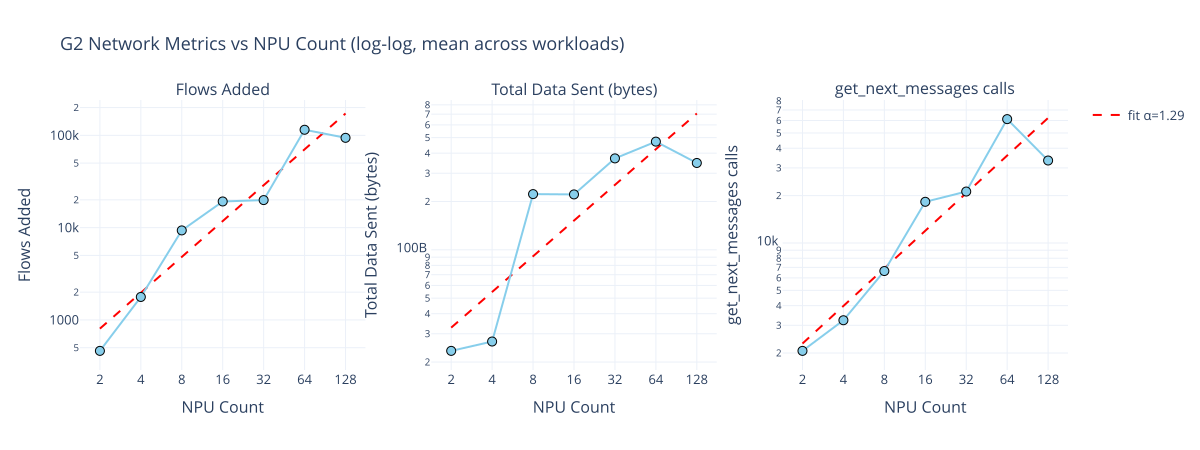

In [5]:
# --- Plot: flows_added, total_data_sent, get_next_messages_calls vs NPU count (log-log) ---

metrics = ['flows_added', 'total_data_sent', 'get_next_messages_calls']
metric_labels = ['Flows Added', 'Total Data Sent (bytes)', 'get_next_messages calls']

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=metric_labels,
)

for col_idx, (metric, label) in enumerate(zip(metrics, metric_labels), start=1):
    agg = df.groupby('npu_count', as_index=False)[metric].mean()
    agg = agg.sort_values('npu_count')

    # Power-law fit
    x_log = np.log10(agg['npu_count'].values)
    y_log = np.log10(agg[metric].values.clip(min=1e-9))
    if len(x_log) >= 2:
        coeffs = np.polyfit(x_log, y_log, 1)
        exponent = coeffs[0]
        x_fit = np.linspace(x_log.min(), x_log.max(), 50)
        y_fit = np.polyval(coeffs, x_fit)
        fig.add_trace(go.Scatter(
            x=10**x_fit, y=10**y_fit,
            mode='lines', name=f'fit α={exponent:.2f}',
            line=dict(dash='dash', width=2, color='red'),
            showlegend=(col_idx == 1),
        ), row=1, col=col_idx)

    fig.add_trace(go.Scatter(
        x=agg['npu_count'], y=agg[metric],
        mode='markers+lines', name=label,
        marker=dict(size=9, color='skyblue', line=dict(width=1, color='black')),
        showlegend=False,
    ), row=1, col=col_idx)

    fig.update_xaxes(title_text='NPU Count', type='log',
                     tickvals=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], row=1, col=col_idx)
    fig.update_yaxes(title_text=label, type='log', row=1, col=col_idx)

fig.update_layout(
    title='G2 Network Metrics vs NPU Count (log-log, mean across workloads)',
    template='plotly_white', font=dict(size=13),
    height=450, width=1200,
)
fig.show()

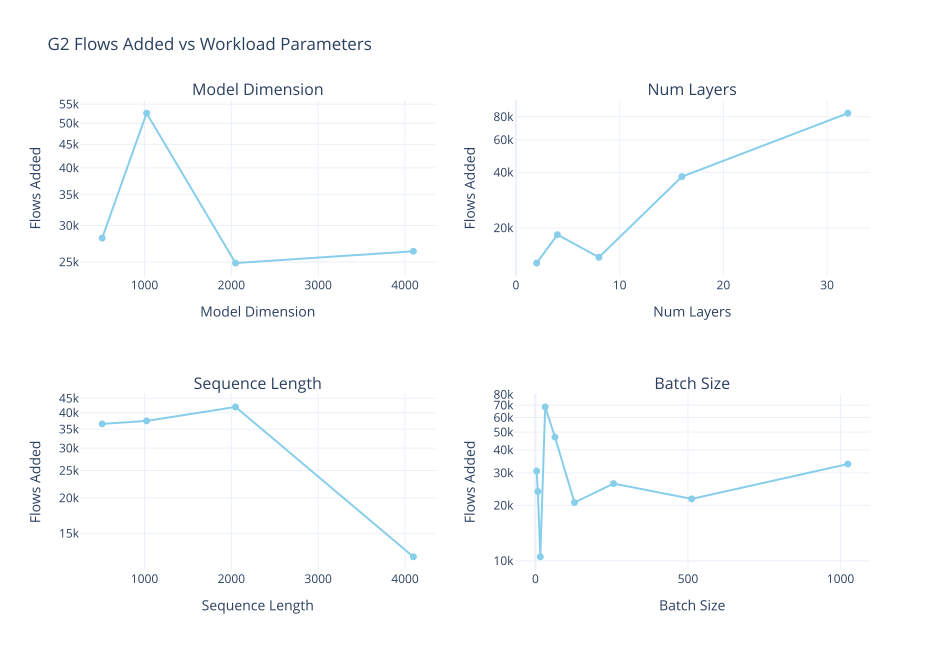

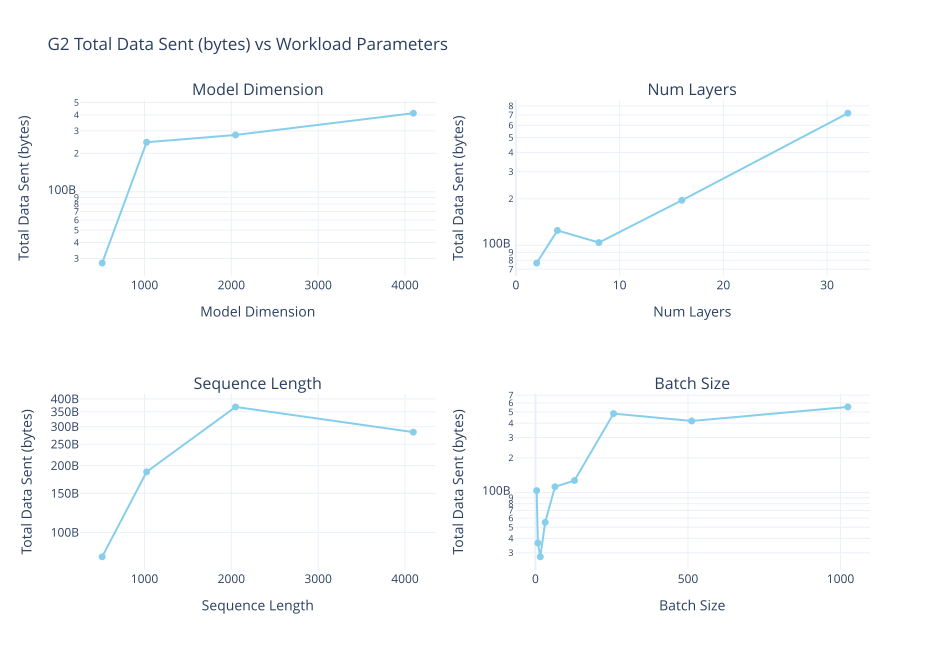

In [6]:
# --- Plot: flows_added and total_data_sent vs workload params (2x2 per metric) ---

param_axis = {
    'd_model': 'Model Dimension',
    'num_stacks': 'Num Layers',
    'seq_len': 'Sequence Length',
    'batch': 'Batch Size',
}

for metric, mlabel in [('flows_added', 'Flows Added'), ('total_data_sent', 'Total Data Sent (bytes)')]:
    fig = make_subplots(rows=2, cols=2, subplot_titles=list(param_axis.values()))
    for idx, (param, plabel) in enumerate(param_axis.items()):
        row, col = divmod(idx, 2)
        row += 1; col += 1
        agg = df.groupby(param, as_index=False)[metric].mean().sort_values(param)
        fig.add_trace(go.Scatter(
            x=agg[param], y=agg[metric],
            mode='lines+markers',
            marker=dict(size=7, color='skyblue'),
            line=dict(color='skyblue', width=2),
            showlegend=False,
        ), row=row, col=col)
        fig.update_xaxes(title_text=plabel, row=row, col=col)
        fig.update_yaxes(title_text=mlabel, type='log', row=row, col=col)

    fig.update_layout(
        title=f'G2 {mlabel} vs Workload Parameters',
        template='plotly_white', font=dict(size=12),
        height=650, width=950,
    )
    fig.show()

## 3. Correlation: What Drives G2 Tracked Time?

Pearson correlations between workload/network metrics and G2 **tracked** time (excluding AstraSim overhead).

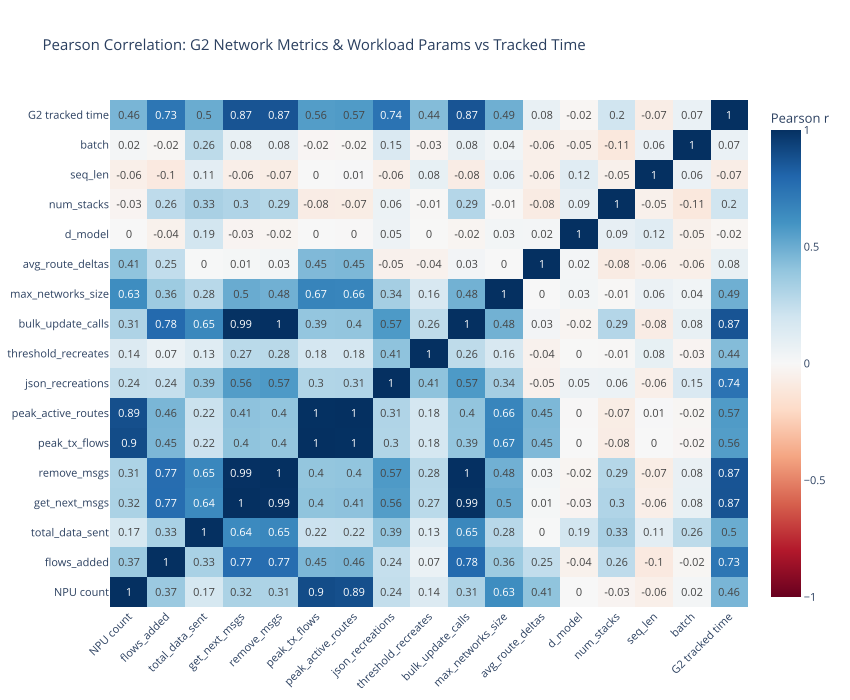

In [7]:
# --- Pearson correlation: network metrics vs tracked_s (G2-only time) ---

corr_cols = [
    'npu_count', 'flows_added', 'total_data_sent', 'get_next_messages_calls',
    'remove_messages_calls', 'peak_transmitting_flows', 'peak_active_flow_routes',
    'json_recreations', 'threshold_recreates', 'bulk_update_calls',
    'max_all_networks_size', 'avg_route_deltas_len',
    'd_model', 'num_stacks', 'seq_len', 'batch',
    'tracked_s',
]
corr_labels = [
    'NPU count', 'flows_added', 'total_data_sent', 'get_next_msgs',
    'remove_msgs', 'peak_tx_flows', 'peak_active_routes',
    'json_recreations', 'threshold_recreates', 'bulk_update_calls',
    'max_networks_size', 'avg_route_deltas',
    'd_model', 'num_stacks', 'seq_len', 'batch',
    'G2 tracked time',
]

sdf = df.dropna(subset=corr_cols)
corr_matrix = sdf[corr_cols].corr(method='pearson').values

fig = go.Figure(go.Heatmap(
    z=corr_matrix, x=corr_labels, y=corr_labels,
    colorscale='RdBu', zmid=0, zmin=-1, zmax=1,
    text=np.round(corr_matrix, 2), texttemplate='%{text}',
    colorbar=dict(title='Pearson r'),
))
fig.update_layout(
    title='Pearson Correlation: G2 Network Metrics & Workload Params vs Tracked Time',
    template='plotly_white', font=dict(size=11),
    height=700, width=850,
    xaxis=dict(tickangle=-45),
)
fig.show()

## 4. Function-Level Time Breakdown

Which internal functions dominate G2 wall-clock time, and how does their share change with NPU count?

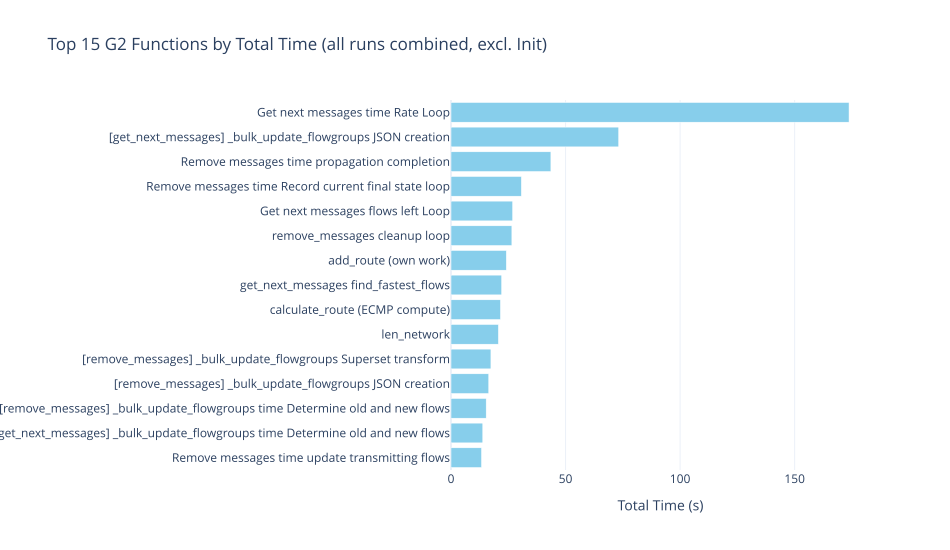

In [8]:
# --- Top functions by total time (aggregated across all runs) ---

# Exclude 'Init function time' as it's a one-time startup cost
et_noinit = et_df[et_df['section'] != 'Init function time'].copy()

top_sections = (
    et_noinit
    .groupby('section', as_index=False)['total_s']
    .sum()
    .sort_values('total_s', ascending=False)
    .head(15)
)

fig = go.Figure(go.Bar(
    y=top_sections['section'],
    x=top_sections['total_s'],
    orientation='h',
    marker_color='skyblue',
))
fig.update_layout(
    title='Top 15 G2 Functions by Total Time (all runs combined, excl. Init)',
    xaxis_title='Total Time (s)',
    yaxis=dict(autorange='reversed'),
    template='plotly_white', font=dict(size=12),
    height=550, width=950,
    margin=dict(l=350),
)
fig.show()

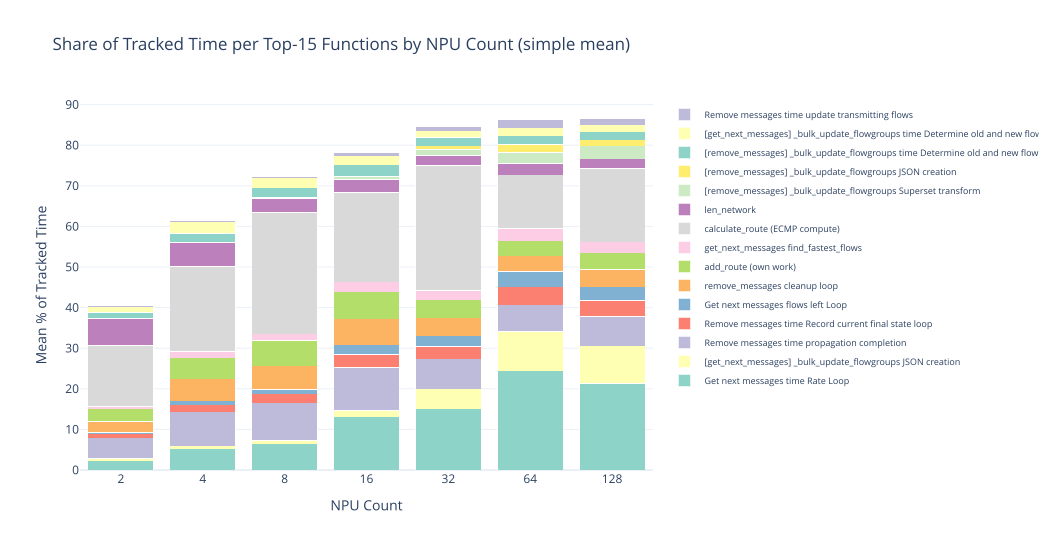

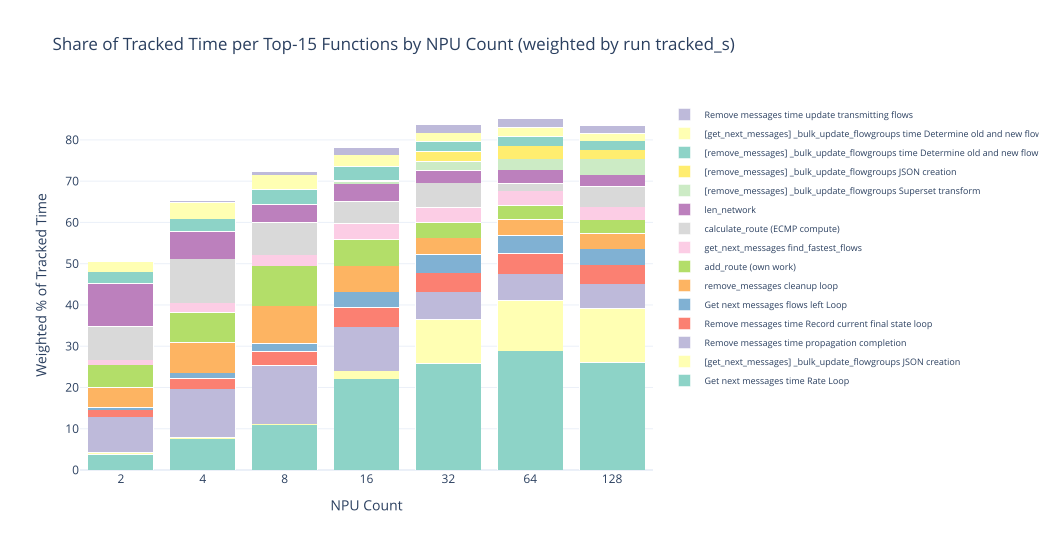

In [9]:
# --- Stacked bar: % of tracked time per function, grouped by NPU count ---
# Two versions: simple mean, and time-weighted mean (weighted by tracked_s of each run)

# Pick top 15 sections by total time
top15_names = top_sections['section'].head(15).tolist()

# Merge tracked_s from df into et_noinit for weighting
et_with_weight = et_noinit[et_noinit['section'].isin(top15_names)].merge(
    df[['workload', 'npu_count', 'run', 'tracked_s']], on=['workload', 'npu_count', 'run']
)

# --- Simple mean (original) ---
pct_by_npu = (
    et_with_weight
    .groupby(['npu_count', 'section'], as_index=False)['pct']
    .mean()
)

fig1 = go.Figure()
colors = px.colors.qualitative.Set3[:len(top15_names)]
for i, sec in enumerate(top15_names):
    sdf = pct_by_npu[pct_by_npu['section'] == sec].sort_values('npu_count')
    fig1.add_trace(go.Bar(
        x=sdf['npu_count'].astype(str), y=sdf['pct'],
        name=sec, marker_color=colors[i % len(colors)],
    ))

fig1.update_layout(
    barmode='stack',
    title='Share of Tracked Time per Top-15 Functions by NPU Count (simple mean)',
    xaxis_title='NPU Count', yaxis_title='Mean % of Tracked Time',
    template='plotly_white', font=dict(size=12),
    height=550, width=1050,
    legend=dict(font=dict(size=9)),
)
fig1.show()

# --- Time-weighted mean: weight each run's pct by its tracked_s ---
def weighted_mean(group):
    w = group['tracked_s']
    total_w = w.sum()
    if total_w == 0:
        return group['pct'].mean()
    return (group['pct'] * w).sum() / total_w

pct_by_npu_weighted = (
    et_with_weight
    .groupby(['npu_count', 'section'])
    .apply(weighted_mean, include_groups=False)
    .reset_index(name='pct_weighted')
)

fig2 = go.Figure()
for i, sec in enumerate(top15_names):
    sdf = pct_by_npu_weighted[pct_by_npu_weighted['section'] == sec].sort_values('npu_count')
    fig2.add_trace(go.Bar(
        x=sdf['npu_count'].astype(str), y=sdf['pct_weighted'],
        name=sec, marker_color=colors[i % len(colors)],
    ))

fig2.update_layout(
    barmode='stack',
    title='Share of Tracked Time per Top-15 Functions by NPU Count (weighted by run tracked_s)',
    xaxis_title='NPU Count', yaxis_title='Weighted % of Tracked Time',
    template='plotly_white', font=dict(size=12),
    height=550, width=1050,
    legend=dict(font=dict(size=9)),
)
fig2.show()

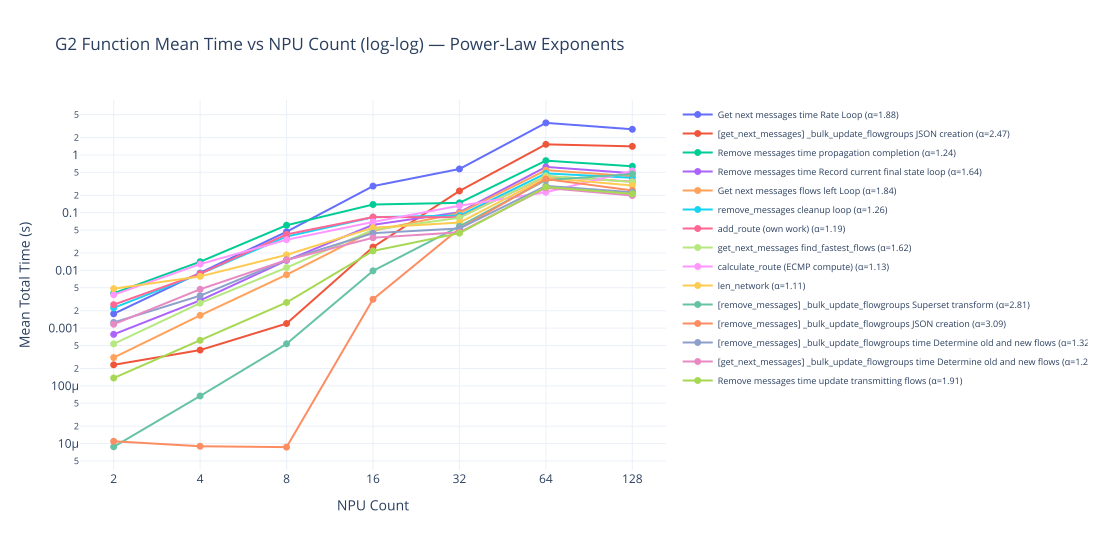

In [10]:
# --- Line plots: absolute time per function vs NPU count (log-log) ---
# Shows how each function's total_s scales with NPU count

fig = go.Figure()
colors = px.colors.qualitative.Plotly + px.colors.qualitative.Set2

for i, sec in enumerate(top15_names):
    agg = (
        et_noinit[et_noinit['section'] == sec]
        .groupby('npu_count', as_index=False)['total_s']
        .mean()
        .sort_values('npu_count')
    )
    if len(agg) < 2:
        continue

    # Power-law fit
    xl = np.log10(agg['npu_count'].values)
    yl = np.log10(agg['total_s'].values.clip(min=1e-9))
    alpha = np.polyfit(xl, yl, 1)[0]

    fig.add_trace(go.Scatter(
        x=agg['npu_count'], y=agg['total_s'],
        mode='lines+markers',
        name=f'{sec} (α={alpha:.2f})',
        marker=dict(size=7),
        line=dict(color=colors[i % len(colors)], width=2),
    ))

fig.update_layout(
    title='G2 Function Mean Time vs NPU Count (log-log) — Power-Law Exponents',
    xaxis_title='NPU Count', yaxis_title='Mean Total Time (s)',
    xaxis_type='log', yaxis_type='log',
    xaxis=dict(tickvals=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]),
    template='plotly_white', font=dict(size=12),
    height=550, width=1100,
    legend=dict(font=dict(size=9)),
)
fig.show()

## 4b. Wall Time vs Tracked Time

Compare the total G2 wall-clock time against the sum of tracked execution sections.  
The gap is **untracked time** (AstraSim overhead, Python interpreter overhead, etc.).

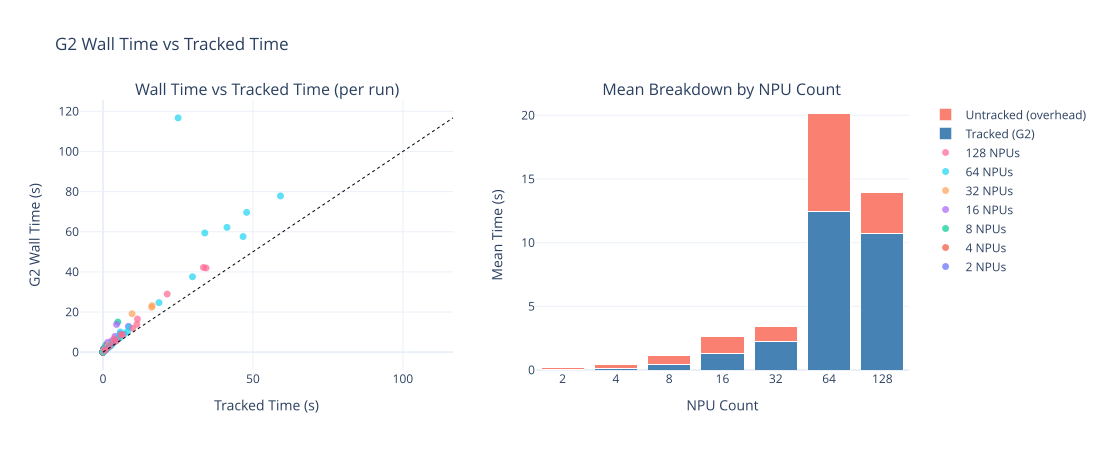


Mean tracked/wall ratio by NPU count:
     2 NPUs: 45.0% tracked
     4 NPUs: 42.8% tracked
     8 NPUs: 50.8% tracked
    16 NPUs: 55.8% tracked
    32 NPUs: 67.5% tracked
    64 NPUs: 70.4% tracked
   128 NPUs: 74.0% tracked


In [11]:
# --- Wall time vs tracked time scatter + breakdown by NPU count ---

fig = make_subplots(rows=1, cols=2,
    subplot_titles=['Wall Time vs Tracked Time (per run)', 'Mean Breakdown by NPU Count'])

# Scatter: wall vs tracked, colored by npu_count
for npu in sorted(df.npu_count.unique()):
    sdf = df[df.npu_count == npu]
    fig.add_trace(go.Scatter(
        x=sdf['tracked_s'], y=sdf['g2_wall_s'],
        mode='markers', name=f'{npu} NPUs',
        marker=dict(size=7, opacity=0.7),
    ), row=1, col=1)

# Perfect line
mn = df[['tracked_s', 'g2_wall_s']].min().min()
mx = df[['tracked_s', 'g2_wall_s']].max().max()
fig.add_trace(go.Scatter(
    x=[mn, mx], y=[mn, mx], mode='lines',
    line=dict(color='black', dash='dot', width=1),
    showlegend=False,
), row=1, col=1)
fig.update_xaxes(title_text='Tracked Time (s)', row=1, col=1)
fig.update_yaxes(title_text='G2 Wall Time (s)', row=1, col=1)

# Stacked bar: tracked vs untracked by NPU count
agg = df.groupby('npu_count', as_index=False).agg(
    mean_tracked=('tracked_s', 'mean'),
    mean_untracked=('untracked_s', 'mean'),
).sort_values('npu_count')

fig.add_trace(go.Bar(
    x=agg['npu_count'].astype(str), y=agg['mean_tracked'],
    name='Tracked (G2)', marker_color='steelblue',
), row=1, col=2)
fig.add_trace(go.Bar(
    x=agg['npu_count'].astype(str), y=agg['mean_untracked'],
    name='Untracked (overhead)', marker_color='salmon',
), row=1, col=2)
fig.update_xaxes(title_text='NPU Count', row=1, col=2)
fig.update_yaxes(title_text='Mean Time (s)', row=1, col=2)

fig.update_layout(
    barmode='stack',
    title='G2 Wall Time vs Tracked Time',
    template='plotly_white', font=dict(size=12),
    height=450, width=1100,
)
fig.show()

# Print ratio
ratio = df.groupby('npu_count').apply(
    lambda g: (g['tracked_s'] / g['g2_wall_s'].clip(lower=1e-9)).mean(), include_groups=False
)
print('\nMean tracked/wall ratio by NPU count:')
for npu, r in ratio.items():
    print(f'  {npu:>4d} NPUs: {r:.1%} tracked')

## 5. Per-Call Cost: Are Individual Calls Getting Slower?

**Key question:** Is G2 slow because there are more calls, or because each call takes longer at higher NPU counts?  
This is the most actionable section — functions where `avg_ms` grows with NPU count are optimization targets.

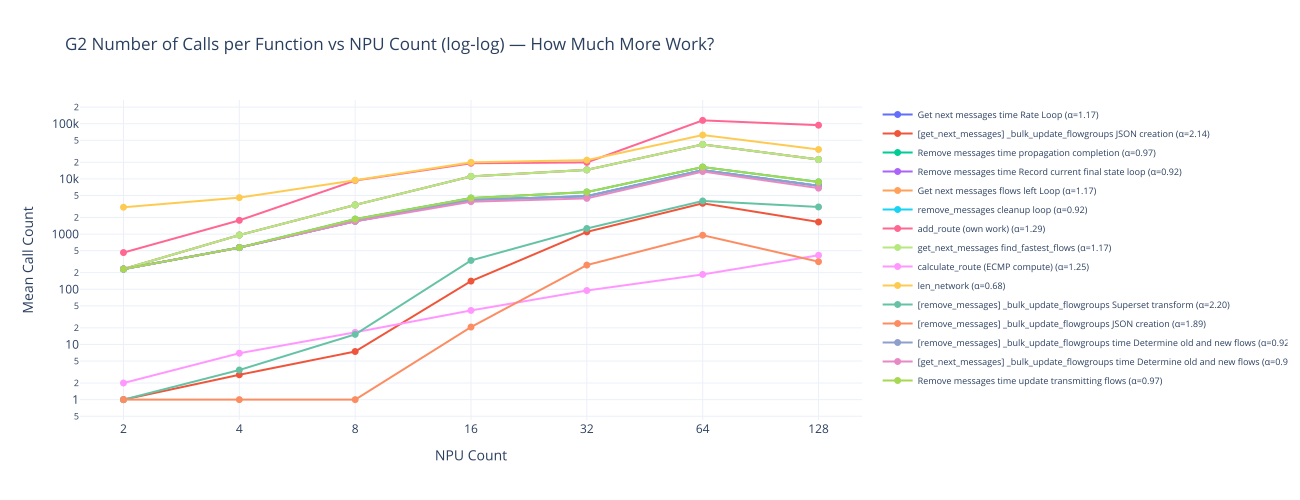

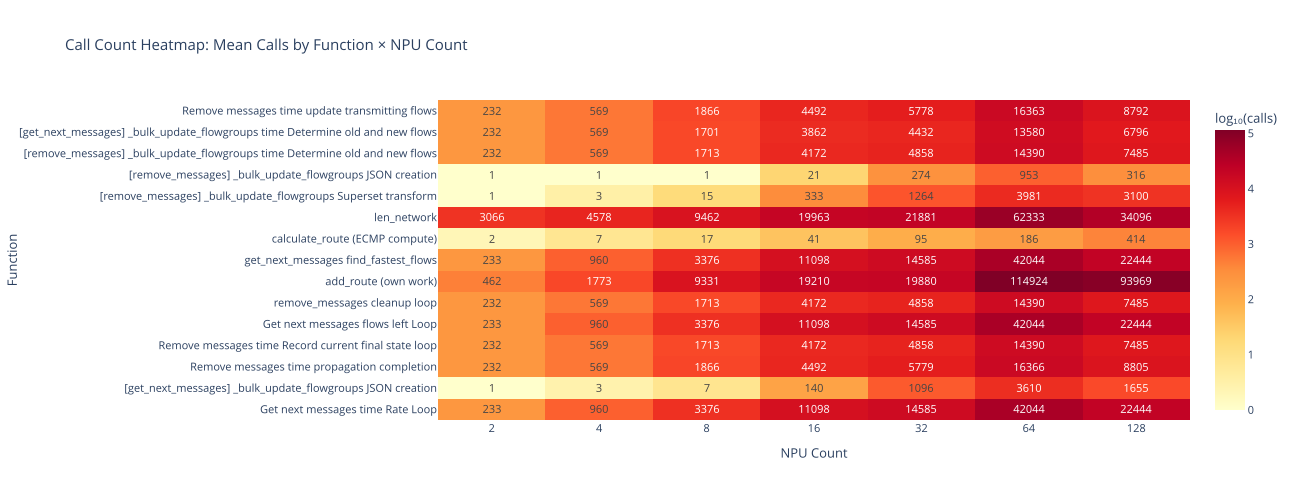

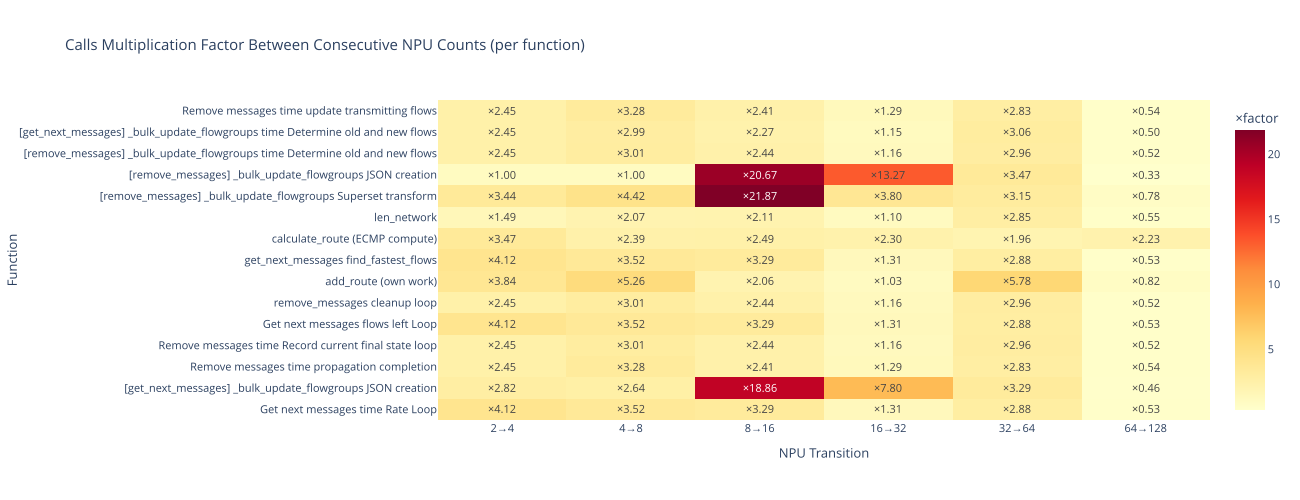

In [12]:

# --- Number of calls per function vs NPU count (log-log) ---

fig = go.Figure()
colors = px.colors.qualitative.Plotly + px.colors.qualitative.Set2

for i, sec in enumerate(top15_names):
    agg = (
        et_noinit[et_noinit['section'] == sec]
        .groupby('npu_count', as_index=False)['calls']
        .mean()
        .sort_values('npu_count')
    )
    if len(agg) < 2:
        continue

    xl = np.log10(agg['npu_count'].values)
    yl = np.log10(agg['calls'].values.clip(min=1e-12))
    alpha = np.polyfit(xl, yl, 1)[0]

    fig.add_trace(go.Scatter(
        x=agg['npu_count'], y=agg['calls'],
        mode='lines+markers',
        name=f'{sec} (α={alpha:.2f})',
        marker=dict(size=7),
        line=dict(color=colors[i % len(colors)], width=2),
    ))

fig.update_layout(
    title='G2 Number of Calls per Function vs NPU Count (log-log) — How Much More Work?',
    xaxis_title='NPU Count', yaxis_title='Mean Call Count',
    xaxis_type='log', yaxis_type='log',
    xaxis=dict(tickvals=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]),
    template='plotly_white', font=dict(size=12),
    height=500, width=1300,
    legend=dict(font=dict(size=9)),
)
fig.show()

# --- Heatmap: absolute call counts per function × NPU count ---

calls_heat = (
    et_noinit[et_noinit['section'].isin(top15_names)]
    .groupby(['section', 'npu_count'], as_index=False)['calls']
    .mean()
    .pivot(index='section', columns='npu_count', values='calls')
    .reindex(top15_names)
)

fig2 = go.Figure(go.Heatmap(
    z=np.log10(calls_heat.values.clip(min=1e-12)),
    x=[str(c) for c in calls_heat.columns],
    y=calls_heat.index,
    colorscale='YlOrRd',
    text=calls_heat.values.round(0).astype(int),
    texttemplate='%{text}',
    colorbar=dict(title='log₁₀(calls)'),
))
fig2.update_layout(
    title='Call Count Heatmap: Mean Calls by Function × NPU Count',
    xaxis_title='NPU Count', yaxis_title='Function',
    template='plotly_white', font=dict(size=11),
    height=500, width=1300,
    margin=dict(l=350),
)
fig2.show()

# --- Heatmap: step-over-step multiplication factor for calls ---

npu_cols = sorted(calls_heat.columns)
mult_labels = [f'{npu_cols[i]}→{npu_cols[i+1]}' for i in range(len(npu_cols) - 1)]
mult_data = pd.DataFrame(index=calls_heat.index, columns=mult_labels)
for i in range(len(npu_cols) - 1):
    prev_vals = calls_heat[npu_cols[i]].values
    next_vals = calls_heat[npu_cols[i + 1]].values
    mult_data[mult_labels[i]] = np.where(prev_vals > 0, next_vals / prev_vals, np.nan)

mult_vals = mult_data.values.astype(float)

fig3 = go.Figure(go.Heatmap(
    z=mult_vals,
    x=mult_labels,
    y=calls_heat.index,
    colorscale='YlOrRd',
    text=np.round(mult_vals, 2),
    texttemplate='×%{text:.2f}',
    colorbar=dict(title='×factor'),
))
fig3.update_layout(
    title='Calls Multiplication Factor Between Consecutive NPU Counts (per function)',
    xaxis_title='NPU Transition', yaxis_title='Function',
    template='plotly_white', font=dict(size=11),
    height=500, width=1300,
    margin=dict(l=350),
)
fig3.show()


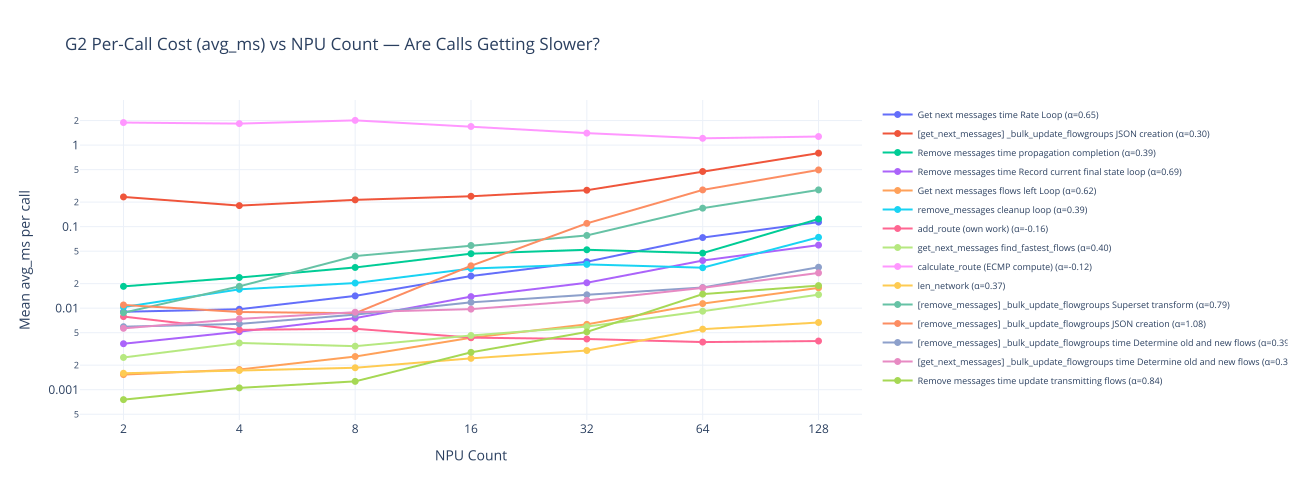

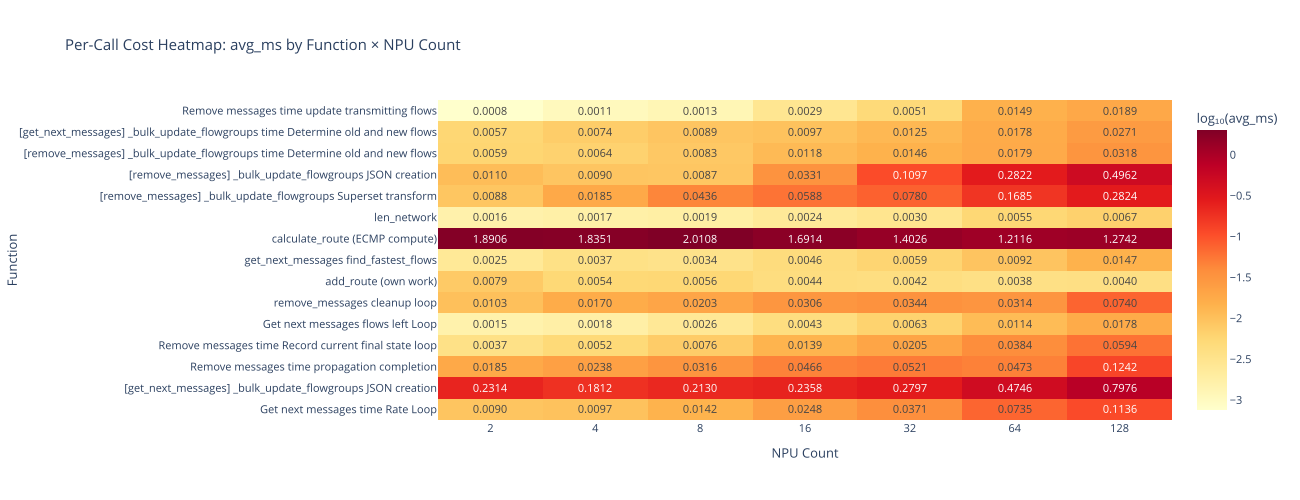

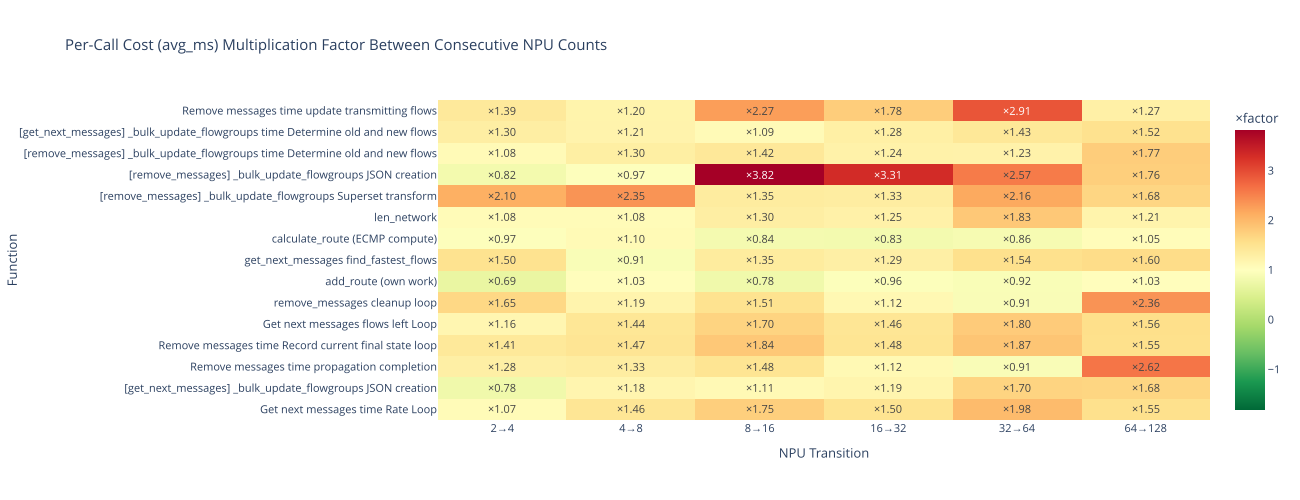

In [13]:

# --- avg_ms per call vs NPU count for top functions ---

fig = go.Figure()
colors = px.colors.qualitative.Plotly + px.colors.qualitative.Set2

for i, sec in enumerate(top15_names):
    agg = (
        et_noinit[et_noinit['section'] == sec]
        .groupby('npu_count', as_index=False)['avg_ms']
        .mean()
        .sort_values('npu_count')
    )
    if len(agg) < 2:
        continue

    xl = np.log10(agg['npu_count'].values)
    yl = np.log10(agg['avg_ms'].values.clip(min=1e-12))
    alpha = np.polyfit(xl, yl, 1)[0]

    fig.add_trace(go.Scatter(
        x=agg['npu_count'], y=agg['avg_ms'],
        mode='lines+markers',
        name=f'{sec} (α={alpha:.2f})',
        marker=dict(size=7),
        line=dict(color=colors[i % len(colors)], width=2),
    ))

fig.update_layout(
    title='G2 Per-Call Cost (avg_ms) vs NPU Count — Are Calls Getting Slower?',
    xaxis_title='NPU Count', yaxis_title='Mean avg_ms per call',
    xaxis_type='log', yaxis_type='log',
    xaxis=dict(tickvals=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]),
    template='plotly_white', font=dict(size=12),
    height=500, width=1300,
    legend=dict(font=dict(size=9)),
)
fig.show()

# --- Heatmap: absolute avg_ms per function × NPU count ---

avgms_heat = (
    et_noinit[et_noinit['section'].isin(top15_names)]
    .groupby(['section', 'npu_count'], as_index=False)['avg_ms']
    .mean()
    .pivot(index='section', columns='npu_count', values='avg_ms')
    .reindex(top15_names)
)

fig2 = go.Figure(go.Heatmap(
    z=np.log10(avgms_heat.values.clip(min=1e-12)),
    x=[str(c) for c in avgms_heat.columns],
    y=avgms_heat.index,
    colorscale='YlOrRd',
    text=avgms_heat.values.round(4),
    texttemplate='%{text:.4f}',
    colorbar=dict(title='log₁₀(avg_ms)'),
))
fig2.update_layout(
    title='Per-Call Cost Heatmap: avg_ms by Function × NPU Count',
    xaxis_title='NPU Count', yaxis_title='Function',
    template='plotly_white', font=dict(size=11),
    height=500, width=1300,
    margin=dict(l=350),
)
fig2.show()

# --- Heatmap: step-over-step multiplication factor for avg_ms ---

npu_cols = sorted(avgms_heat.columns)
mult_labels = [f'{npu_cols[i]}→{npu_cols[i+1]}' for i in range(len(npu_cols) - 1)]
mult_data = pd.DataFrame(index=avgms_heat.index, columns=mult_labels)
for i in range(len(npu_cols) - 1):
    prev_vals = avgms_heat[npu_cols[i]].values
    next_vals = avgms_heat[npu_cols[i + 1]].values
    mult_data[mult_labels[i]] = np.where(prev_vals > 1e-12, next_vals / prev_vals, np.nan)

mult_vals = mult_data.values.astype(float)

fig3 = go.Figure(go.Heatmap(
    z=mult_vals,
    x=mult_labels,
    y=avgms_heat.index,
    colorscale='RdYlGn_r',  # red = getting slower, green = stable/improving
    zmid=1.0,
    text=np.round(mult_vals, 2),
    texttemplate='×%{text:.2f}',
    colorbar=dict(title='×factor'),
))
fig3.update_layout(
    title='Per-Call Cost (avg_ms) Multiplication Factor Between Consecutive NPU Counts',
    xaxis_title='NPU Transition', yaxis_title='Function',
    template='plotly_white', font=dict(size=11),
    height=500, width=1300,
    margin=dict(l=350),
)
fig3.show()


In [14]:
# --- Decomposition: total_time = calls × avg_time_per_call ---
# Show which factor dominates growth for each function (not just top15)

all_sections = et_noinit['section'].unique()
decomp_rows = []
for sec in all_sections:
    agg = (
        et_noinit[et_noinit['section'] == sec]
        .groupby('npu_count', as_index=False)
        .agg(mean_total_s=('total_s', 'mean'), mean_calls=('calls', 'mean'), mean_avg_ms=('avg_ms', 'mean'))
        .sort_values('npu_count')
    )
    if len(agg) < 2 or agg['mean_total_s'].max() < 1e-6:
        continue
    xl = np.log10(agg['npu_count'].values)
    alpha_time = np.polyfit(xl, np.log10(agg['mean_total_s'].values.clip(min=1e-12)), 1)[0]
    alpha_calls = np.polyfit(xl, np.log10(agg['mean_calls'].values.clip(min=1e-12)), 1)[0]
    alpha_per_call = np.polyfit(xl, np.log10(agg['mean_avg_ms'].values.clip(min=1e-12)), 1)[0]

    # Get avg_ms at smallest and largest NPU count
    avg_ms_min_npu = agg.iloc[0]['mean_avg_ms']
    avg_ms_max_npu = agg.iloc[-1]['mean_avg_ms']

    decomp_rows.append({
        'Function': sec,
        'α(total_time)': round(alpha_time, 3),
        'α(num_calls)': round(alpha_calls, 3),
        'α(per_call_ms)': round(alpha_per_call, 3),
        f'avg_ms @{int(agg.iloc[0]["npu_count"])}NPU': round(avg_ms_min_npu, 5),
        f'avg_ms @{int(agg.iloc[-1]["npu_count"])}NPU': round(avg_ms_max_npu, 5),
        'slowdown_factor': round(avg_ms_max_npu / max(avg_ms_min_npu, 1e-12), 1),
        'Dominant growth': 'more calls' if alpha_calls > alpha_per_call else 'slower calls',
    })

decomp_df = pd.DataFrame(decomp_rows).sort_values('α(total_time)', ascending=False)
print('Time growth decomposition: α(total) ≈ α(calls) + α(per_call)')
print('  - α(calls) >> α(per_call) → slowness from more calls (workload-driven)')
print('  - α(per_call) >> α(calls) → each call gets slower (algorithmic issue)')
print(f'  - slowdown_factor = avg_ms at max NPU / avg_ms at min NPU\n')
display(decomp_df.head(20).style.format(precision=3).background_gradient(
    subset=['α(total_time)', 'α(per_call_ms)'], cmap='Reds'
).background_gradient(
    subset=['slowdown_factor'], cmap='YlOrRd'
))

Time growth decomposition: α(total) ≈ α(calls) + α(per_call)
  - α(calls) >> α(per_call) → slowness from more calls (workload-driven)
  - α(per_call) >> α(calls) → each call gets slower (algorithmic issue)
  - slowdown_factor = avg_ms at max NPU / avg_ms at min NPU



,Function,α(total_time),α(num_calls),α(per_call_ms),avg_ms @2NPU,avg_ms @128NPU,slowdown_factor,Dominant growth,avg_ms @4NPU
26,[remove_messages] _bulk_update_flowgroups JSON creation,3.094,1.886,1.076,0.011,0.496,45.300,more calls,nan
31,[remove_messages] _bulk_update_flowgroups Superset lookup,3.047,2.213,0.863,0.002,0.048,29.200,more calls,nan
29,[get_next_messages] _bulk_update_flowgroups Superset transform,2.891,1.837,0.881,nan,0.490,18.800,more calls,0.026
32,[get_next_messages] _bulk_update_flowgroups Superset lookup,2.818,2.126,0.650,0.003,0.041,12.400,more calls,nan
24,[remove_messages] _bulk_update_flowgroups Superset transform,2.811,2.197,0.794,0.009,0.282,32.100,more calls,nan
18,[get_next_messages] _bulk_update_flowgroups JSON creation,2.465,2.140,0.305,0.231,0.798,3.400,more calls,nan
36,[remove_messages] _bulk_update_flowgroups Sequential updates,2.337,1.709,0.531,0.022,0.171,7.900,more calls,nan
11,Remove messages time update transmitting flows,1.908,0.966,0.843,0.001,0.019,25.000,more calls,nan
0,Get next messages time Rate Loop,1.884,1.171,0.650,0.009,0.114,12.600,more calls,nan
5,Get next messages flows left Loop,1.841,1.171,0.617,0.002,0.018,11.600,more calls,nan


## 6. Cache Efficiency

How do cache hit rates and JSON recreations change with scale?

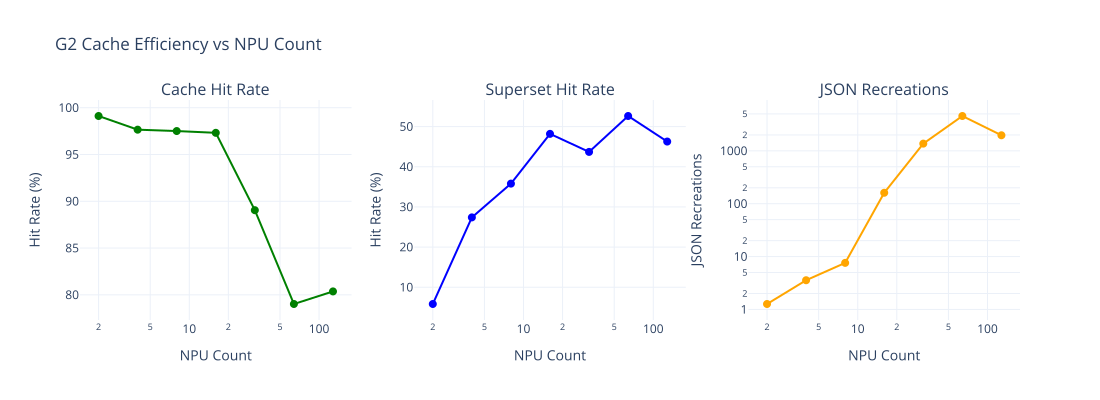

In [15]:
# --- Cache metrics vs NPU count ---

df['cache_hit_rate'] = df['cache_hits'] / (df['cache_hits'] + df['json_recreations']).clip(lower=1)
df['superset_hit_rate'] = df['superset_hits'] / (df['superset_hits'] + df['superset_misses']).clip(lower=1)

fig = make_subplots(rows=1, cols=3,
    subplot_titles=['Cache Hit Rate', 'Superset Hit Rate', 'JSON Recreations'])

agg1 = df.groupby('npu_count', as_index=False)['cache_hit_rate'].mean().sort_values('npu_count')
fig.add_trace(go.Scatter(x=agg1['npu_count'], y=agg1['cache_hit_rate'] * 100,
    mode='lines+markers', marker=dict(size=8, color='green'), showlegend=False), row=1, col=1)
fig.update_xaxes(title_text='NPU Count', type='log', row=1, col=1)
fig.update_yaxes(title_text='Hit Rate (%)', row=1, col=1)

agg2 = df.groupby('npu_count', as_index=False)['superset_hit_rate'].mean().sort_values('npu_count')
fig.add_trace(go.Scatter(x=agg2['npu_count'], y=agg2['superset_hit_rate'] * 100,
    mode='lines+markers', marker=dict(size=8, color='blue'), showlegend=False), row=1, col=2)
fig.update_xaxes(title_text='NPU Count', type='log', row=1, col=2)
fig.update_yaxes(title_text='Hit Rate (%)', row=1, col=2)

agg3 = df.groupby('npu_count', as_index=False)['json_recreations'].mean().sort_values('npu_count')
fig.add_trace(go.Scatter(x=agg3['npu_count'], y=agg3['json_recreations'],
    mode='lines+markers', marker=dict(size=8, color='orange'), showlegend=False), row=1, col=3)
fig.update_xaxes(title_text='NPU Count', type='log', row=1, col=3)
fig.update_yaxes(title_text='JSON Recreations', type='log', row=1, col=3)

fig.update_layout(
    title='G2 Cache Efficiency vs NPU Count',
    template='plotly_white', font=dict(size=12),
    height=400, width=1100,
)
fig.show()

## 7. Multi-Variable Regression: What Drives G2 Tracked Time?

Fit `log10(tracked_s) ~ a*log10(flows_added) + b*log10(total_hops) + c*log10(npu_count) + ...`  
Uses only G2 tracked time (excludes AstraSim overhead).

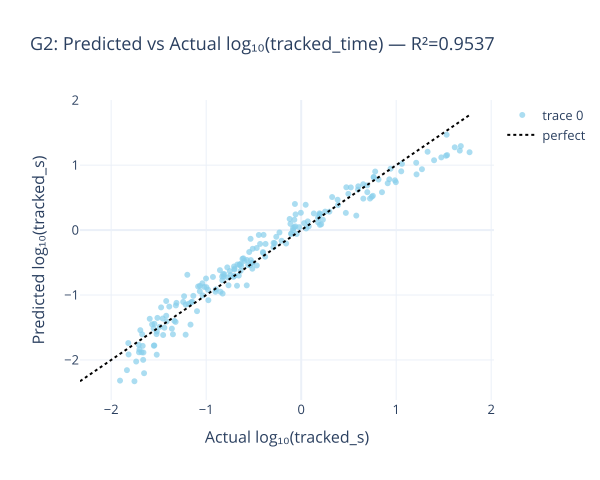


R² = 0.9537
Intercept: -3.2605
  log(                   npu_count)  coef = +0.7092
  log(                 flows_added)  coef = -0.0015
  log(             total_data_sent)  coef = -0.1550
  log(     get_next_messages_calls)  coef = +0.0369
  log(           bulk_update_calls)  coef = +0.7971
  log(            json_recreations)  coef = -0.0547
  log(                     d_model)  coef = +0.2053
  log(                     seq_len)  coef = +0.0889
  log(                       batch)  coef = +0.0866


In [16]:
# --- Log-linear regression with network metrics as features (tracked_s only) ---

# Add log_tracked_s
df['log_tracked_s'] = np.log10(df['tracked_s'].clip(lower=eps))

reg_features_raw = ['npu_count', 'flows_added', 'total_data_sent', 'get_next_messages_calls',
                    'bulk_update_calls', 'json_recreations', 'd_model', 'seq_len', 'batch']
reg_features = [f'log_{c}' for c in reg_features_raw]
target = 'log_tracked_s'

# Build log features that might not exist yet
for c in reg_features_raw:
    lc = f'log_{c}'
    if lc not in df.columns:
        df[lc] = np.log10(df[c].clip(lower=eps))

sdf = df.dropna(subset=reg_features + [target])
mask = np.isfinite(sdf[reg_features + [target]]).all(axis=1)
sdf = sdf[mask]

X = sdf[reg_features].values
y = sdf[target].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = model.score(X, y)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=y, y=y_pred, mode='markers',
    marker=dict(color='skyblue', size=6, opacity=0.7),
))
mn, mx = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
fig.add_trace(go.Scatter(x=[mn, mx], y=[mn, mx], mode='lines', line=dict(color='black', dash='dot'), name='perfect'))
fig.update_layout(
    title=f'G2: Predicted vs Actual log₁₀(tracked_time) — R²={r2:.4f}',
    xaxis_title='Actual log₁₀(tracked_s)', yaxis_title='Predicted log₁₀(tracked_s)',
    template='plotly_white', font=dict(size=13), height=480, width=600,
)
fig.show()

print(f'\nR² = {r2:.4f}')
print(f'Intercept: {model.intercept_:.4f}')
for feat, coef in zip(reg_features_raw, model.coef_):
    print(f'  log({feat:>28s})  coef = {coef:+.4f}')

## 8. Hops per Flow & Peak Concurrency

Derived metrics that highlight structural complexity.

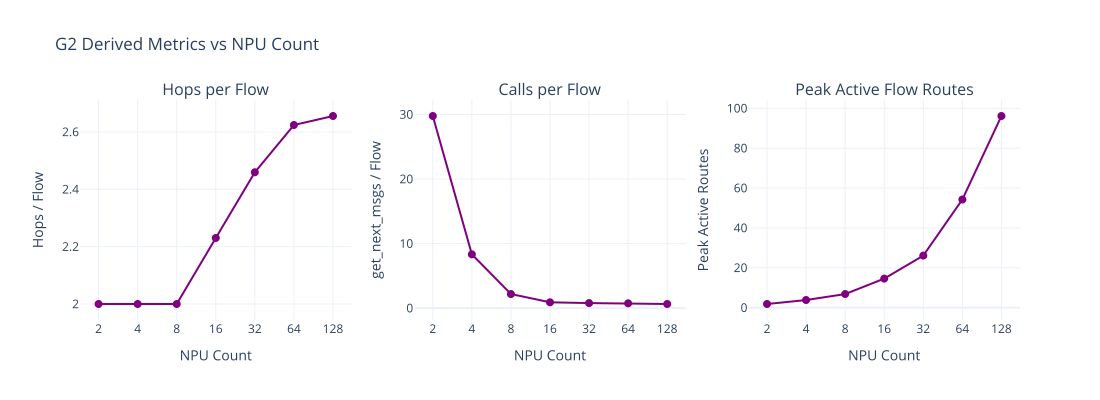

In [17]:
# --- Derived metrics ---

df['hops_per_flow'] = df['total_hops'] / df['flows_added'].clip(lower=1)
df['calls_per_flow'] = df['get_next_messages_calls'] / df['flows_added'].clip(lower=1)

fig = make_subplots(rows=1, cols=3,
    subplot_titles=['Hops per Flow', 'Calls per Flow', 'Peak Active Flow Routes'])

for col_idx, (metric, label) in enumerate([
    ('hops_per_flow', 'Hops / Flow'),
    ('calls_per_flow', 'get_next_msgs / Flow'),
    ('peak_active_flow_routes', 'Peak Active Routes'),
], start=1):
    agg = df.groupby('npu_count', as_index=False)[metric].mean().sort_values('npu_count')
    fig.add_trace(go.Scatter(
        x=agg['npu_count'], y=agg[metric],
        mode='lines+markers', marker=dict(size=8, color='purple'),
        showlegend=False,
    ), row=1, col=col_idx)
    fig.update_xaxes(title_text='NPU Count', type='log',
                     tickvals=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], row=1, col=col_idx)
    fig.update_yaxes(title_text=label, row=1, col=col_idx)

fig.update_layout(
    title='G2 Derived Metrics vs NPU Count',
    template='plotly_white', font=dict(size=12),
    height=400, width=1100,
)
fig.show()

## 9. Marginal Cost per Flow / Hop

Normalize G2 tracked time by flows and hops to see if the per-unit cost grows with scale.

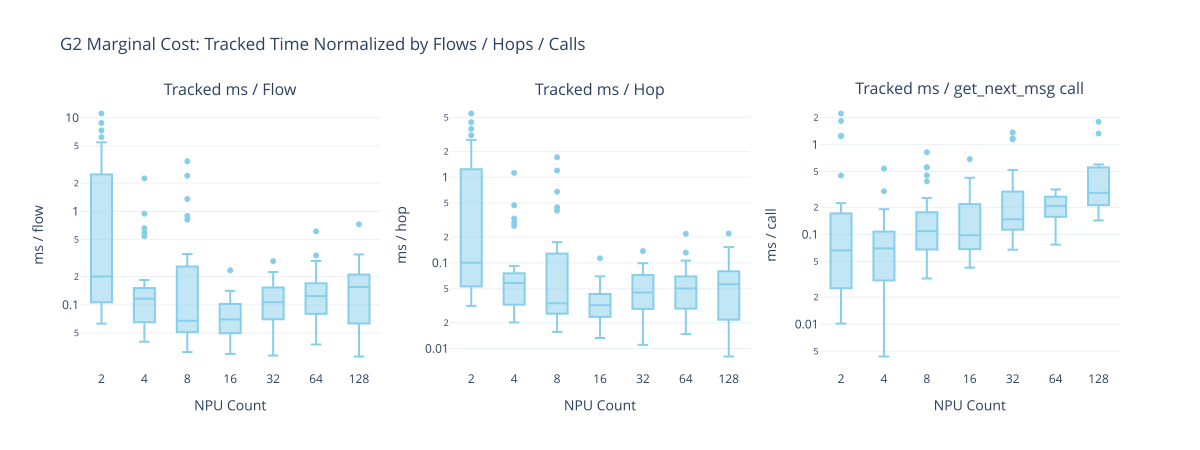

In [18]:
# --- Tracked time normalized by flows / hops (excludes AstraSim overhead) ---

df['tracked_ms_per_flow'] = 1000 * df['tracked_s'] / df['flows_added'].clip(lower=1)
df['tracked_ms_per_hop'] = 1000 * df['tracked_s'] / df['total_hops'].clip(lower=1)
df['tracked_ms_per_gnm_call'] = 1000 * df['tracked_s'] / df['get_next_messages_calls'].clip(lower=1)

fig = make_subplots(rows=1, cols=3,
    subplot_titles=['Tracked ms / Flow', 'Tracked ms / Hop', 'Tracked ms / get_next_msg call'])

for col_idx, (metric, label) in enumerate([
    ('tracked_ms_per_flow', 'ms / flow'),
    ('tracked_ms_per_hop', 'ms / hop'),
    ('tracked_ms_per_gnm_call', 'ms / call'),
], start=1):
    for npu in sorted(df.npu_count.unique()):
        sdf = df[df.npu_count == npu]
        fig.add_trace(go.Box(
            y=sdf[metric], name=str(npu),
            marker_color='skyblue',
            showlegend=False,
        ), row=1, col=col_idx)
    fig.update_yaxes(title_text=label, type='log', row=1, col=col_idx)
    fig.update_xaxes(title_text='NPU Count', row=1, col=col_idx)

fig.update_layout(
    title='G2 Marginal Cost: Tracked Time Normalized by Flows / Hops / Calls',
    template='plotly_white', font=dict(size=12),
    height=450, width=1200,
)
fig.show()

## 10. Summary Table

Compact overview of key metrics per NPU tier (G2 tracked time only).

In [19]:
# --- Summary table (tracked time only, no AstraSim overhead) ---

summary = df.groupby('npu_count').agg(
    n_runs=('workload', 'count'),
    mean_tracked_s=('tracked_s', 'mean'),
    median_tracked_s=('tracked_s', 'median'),
    max_tracked_s=('tracked_s', 'max'),
    mean_wall_s=('g2_wall_s', 'mean'),
    mean_untracked_s=('untracked_s', 'mean'),
    mean_flows=('flows_added', 'mean'),
    mean_data_sent=('total_data_sent', 'mean'),
    mean_gnm_calls=('get_next_messages_calls', 'mean'),
    mean_peak_routes=('peak_active_flow_routes', 'mean'),
    mean_json_recreations=('json_recreations', 'mean'),
    mean_bulk_updates=('bulk_update_calls', 'mean'),
    mean_hops_per_flow=('hops_per_flow', 'mean'),
    mean_tracked_ms_per_flow=('tracked_ms_per_flow', 'mean'),
).round(2)

print('G2 Performance Summary by NPU Count (tracked time only):')
display(summary.style.format(precision=2).background_gradient(cmap='YlOrRd'))

G2 Performance Summary by NPU Count (tracked time only):


,n_runs,mean_tracked_s,median_tracked_s,max_tracked_s,mean_wall_s,mean_untracked_s,mean_flows,mean_data_sent,mean_gnm_calls,mean_peak_routes,mean_json_recreations,mean_bulk_updates,mean_hops_per_flow,mean_tracked_ms_per_flow
npu_count,,,,,,,,,,,,,,
2,30,0.05,0.02,0.23,0.22,0.17,462.13,23469367842.13,2063.33,1.87,1.27,464.27,2.00,1.92
4,30,0.12,0.06,0.62,0.38,0.26,1773.20,26837935718.40,3229.77,3.87,3.57,1137.73,2.00,0.25
8,30,0.43,0.15,4.97,1.15,0.72,9331.47,222346503782.40,6634.77,6.87,7.60,3414.03,2.00,0.37
16,30,1.31,0.38,8.47,2.58,1.28,19209.60,221373040776.53,18269.83,14.60,161.10,8033.27,2.23,0.08
32,29,2.22,0.59,16.38,3.38,1.16,19879.72,371109089138.76,21228.48,26.14,1370.31,9290.24,2.46,0.12
64,30,12.45,4.46,59.19,20.14,7.69,114924.00,472055982762.67,61239.67,54.27,4563.30,27969.53,2.62,0.15
128,14,10.70,6.26,34.37,13.92,3.22,93969.14,347565757001.14,33427.43,96.14,1971.14,14280.93,2.66,0.19


## 11. Memory Tracker CSV Analysis

Read the periodic `*_memory.csv` files produced by the `MemoryTracker` background thread.
Each row is a time-stamped snapshot (every N seconds) with process RSS/VMS and per-cache-entry flow/link counts.

Plots:
1. **RSS over time** per run (largest NPU counts)
2. **Peak RSS by NPU count** — mean/max + box distribution
3. **RSS vs cache metrics** (avg flows, avg links, cache entries) — scatter with Pearson r
4. **Correlation heatmap** — RSS vs all tracked metrics

In [22]:
# --- Collect all *_memory.csv files from MemoryTracker ---

mt_rows = []

for npu_dir in sorted(os.listdir(topo_base)):
    npu_path = os.path.join(topo_base, npu_dir)
    if not os.path.isdir(npu_path) or not npu_dir.startswith('npu_'):
        continue
    npu_count = int(npu_dir.split('_')[1])

    for workload_name in os.listdir(npu_path):
        workload_path = os.path.join(npu_path, workload_name)
        if not os.path.isdir(workload_path):
            continue
        wparams = parse_workload_params(workload_name)
        if not wparams:
            continue

        for run_dir_name in os.listdir(workload_path):
            if not run_dir_name.startswith('run_g2'):
                continue
            run_path = os.path.join(workload_path, run_dir_name)
            g2_path = os.path.join(run_path, 'g2')
            if not os.path.isdir(g2_path):
                continue

            # Only pick MemoryTracker CSVs (ends with link_traffic.csv_memory.csv),
            # not the AstraSim system memory log (*_memory.csv without link_traffic)
            csv_files = [f for f in os.listdir(g2_path)
                         if f.endswith('_memory.csv') and 'link_traffic' in f]
            if not csv_files:
                continue

            csv_path = os.path.join(g2_path, csv_files[0])
            try:
                chunk = pd.read_csv(csv_path)
            except Exception:
                continue

            chunk['npu_count'] = npu_count
            chunk['workload'] = workload_name
            chunk['run'] = run_dir_name
            for k, v in wparams.items():
                chunk[k] = v
            mt_rows.append(chunk)

if mt_rows:
    mt_df = pd.concat(mt_rows, ignore_index=True)
    n_runs = mt_df.groupby(['npu_count', 'workload', 'run']).ngroups
    print(f'Loaded {len(mt_df)} memory snapshots from {n_runs} runs')
    print(f'NPU counts: {sorted(mt_df.npu_count.unique())}')
    print(f'Columns: {list(mt_df.columns)}')
    display(mt_df.head())
else:
    mt_df = pd.DataFrame()
    print('No *_memory.csv files found. Re-run simulations with MemoryTracker enabled.')

Loaded 521 memory snapshots from 214 runs
NPU counts: [2, 4, 8, 16, 32, 64, 128, 256]
Columns: ['timestamp', 'elapsed_s', 'rss_mb', 'vms_mb', 'cache_entries', 'avg_flows_per_cached_net', 'avg_links_per_cached_net', 'max_flows_in_cache', 'max_links_in_cache', 'total_topology_links', 'num_npus', 'npu_count', 'workload', 'run', 'd_model', 'num_stacks', 'seq_len', 'batch', 'micro_batch', 'dp', 'tp', 'sp', 'pp', 'weight_sharded']


,timestamp,elapsed_s,rss_mb,vms_mb,cache_entries,avg_flows_per_cached_net,avg_links_per_cached_net,max_flows_in_cache,max_links_in_cache,total_topology_links,...,d_model,num_stacks,seq_len,batch,micro_batch,dp,tp,sp,pp,weight_sharded
0,1.773340e+09,0.0000,139.62,290.57,0,0.00,0.00,0,0,2368,...,4096,32,2048,4,4,2,1,32,2,1
1,1.773340e+09,10.0268,219.11,370.08,84,51.62,117.62,128,256,2368,...,4096,32,2048,4,4,2,1,32,2,1
2,1.773340e+09,20.0613,290.78,442.03,200,100.56,163.12,128,224,2368,...,4096,32,2048,4,4,2,1,32,2,1
3,1.773340e+09,0.0000,103.88,254.94,0,0.00,0.00,0,0,2368,...,4096,16,4096,256,32,4,2,1,16,1
4,1.773340e+09,0.0000,202.63,353.55,0,0.00,0.00,0,0,2368,...,512,16,2048,256,64,32,1,2,2,0


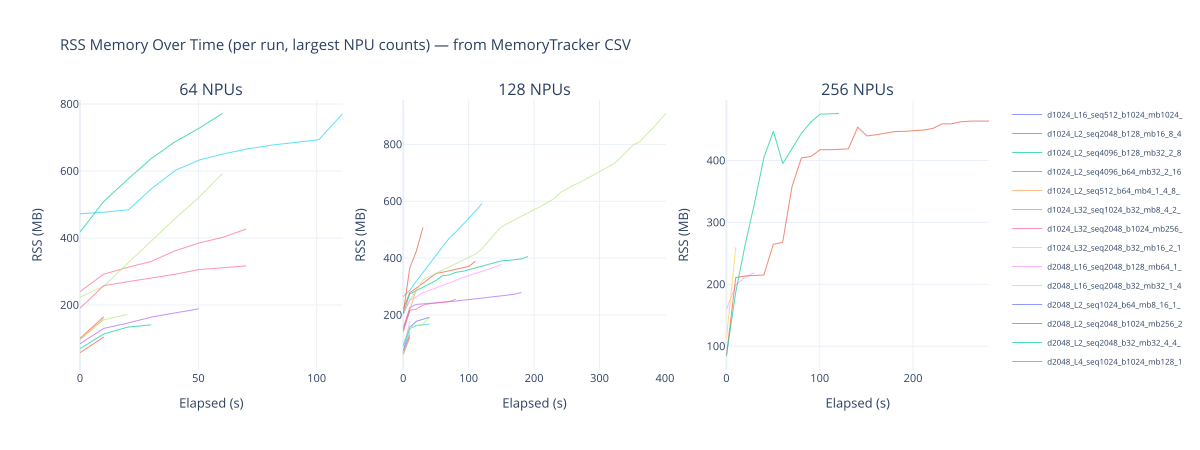

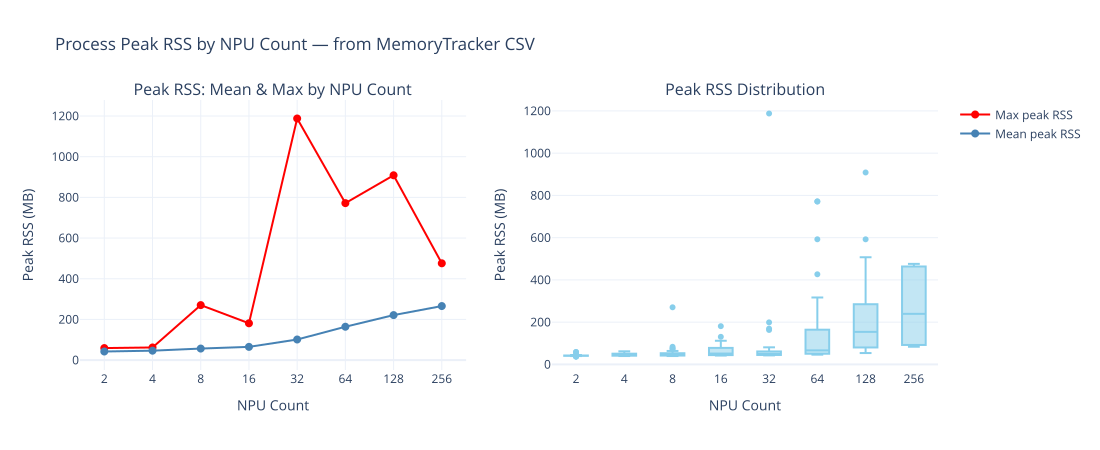

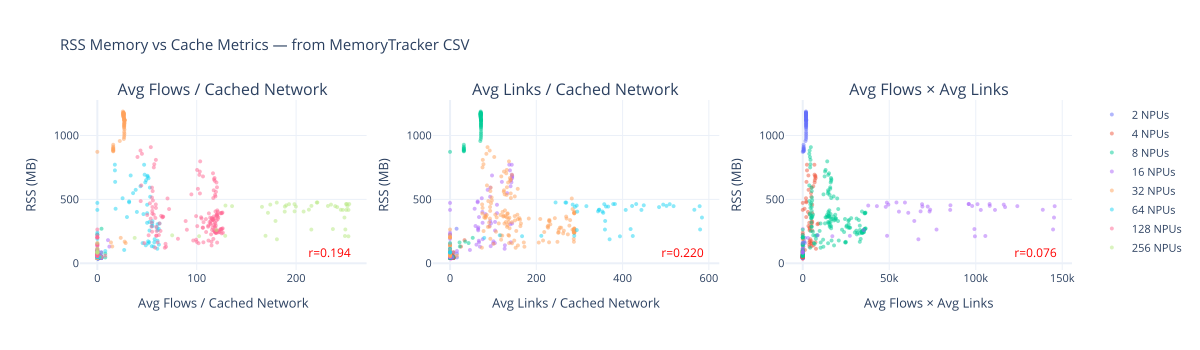

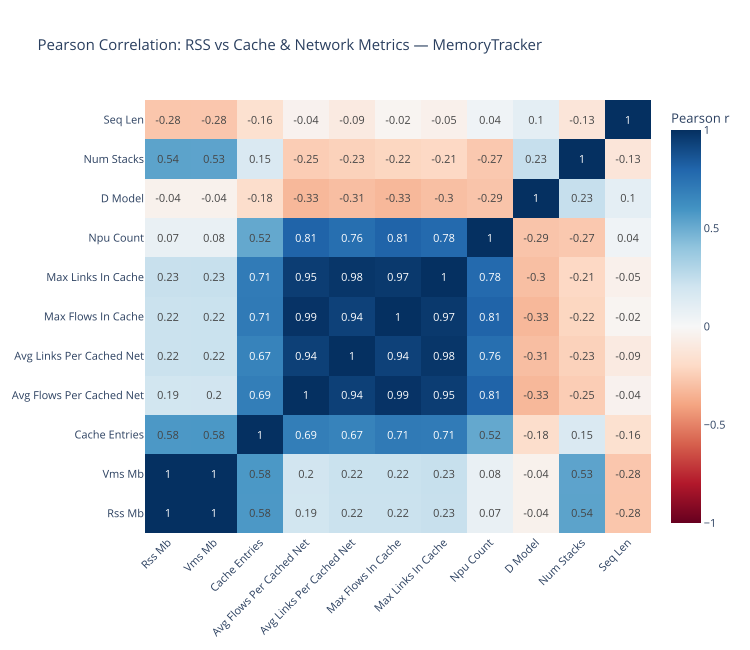


Pearson correlation with RSS (MB)  [MemoryTracker snapshots]:
                          vms_mb: +1.000
                   cache_entries: +0.578
                      num_stacks: +0.537
              max_links_in_cache: +0.230
        avg_links_per_cached_net: +0.220
              max_flows_in_cache: +0.220
        avg_flows_per_cached_net: +0.194
                       npu_count: +0.074
                         d_model: -0.044
                         seq_len: -0.277


In [23]:
# --- Plot 1: RSS over time per run (top 3 NPU counts) ---

if not mt_df.empty:
    top_npus = sorted(mt_df.npu_count.unique())[-3:]

    fig = make_subplots(rows=1, cols=len(top_npus),
        subplot_titles=[f'{n} NPUs' for n in top_npus])

    for col_idx, npu in enumerate(top_npus, start=1):
        npu_data = mt_df[mt_df.npu_count == npu]
        for (wl, run), grp in npu_data.groupby(['workload', 'run']):
            grp = grp.sort_values('elapsed_s')
            fig.add_trace(go.Scatter(
                x=grp['elapsed_s'], y=grp['rss_mb'],
                mode='lines', name=f'{wl[:30]}',
                line=dict(width=1), opacity=0.7,
                showlegend=(col_idx == 1),
            ), row=1, col=col_idx)
        fig.update_xaxes(title_text='Elapsed (s)', row=1, col=col_idx)
        fig.update_yaxes(title_text='RSS (MB)', row=1, col=col_idx)

    fig.update_layout(
        title='RSS Memory Over Time (per run, largest NPU counts) — from MemoryTracker CSV',
        template='plotly_white', font=dict(size=11),
        height=450, width=1200,
        legend=dict(font=dict(size=8)),
    )
    fig.show()

    # --- Plot 2: Peak RSS by NPU count (mean/max bar + box) ---

    peak_per_run = (
        mt_df.groupby(['npu_count', 'workload', 'run'], as_index=False)['rss_mb'].max()
        .rename(columns={'rss_mb': 'peak_rss_mb'})
    )

    fig2 = make_subplots(rows=1, cols=2,
        subplot_titles=['Peak RSS: Mean & Max by NPU Count', 'Peak RSS Distribution'])

    agg = peak_per_run.groupby('npu_count')['peak_rss_mb'].agg(['mean', 'max']).reset_index()
    agg.columns = ['npu_count', 'mean_rss', 'max_rss']
    agg = agg.sort_values('npu_count')

    fig2.add_trace(go.Scatter(
        x=agg['npu_count'], y=agg['max_rss'],
        mode='lines+markers', name='Max peak RSS',
        marker=dict(size=8, color='red'),
    ), row=1, col=1)
    fig2.add_trace(go.Scatter(
        x=agg['npu_count'], y=agg['mean_rss'],
        mode='lines+markers', name='Mean peak RSS',
        marker=dict(size=8, color='steelblue'),
    ), row=1, col=1)
    fig2.update_xaxes(title_text='NPU Count', type='log',
                      tickvals=[2, 4, 8, 16, 32, 64, 128, 256, 512, 1024], row=1, col=1)
    fig2.update_yaxes(title_text='Peak RSS (MB)', row=1, col=1)

    for npu in sorted(peak_per_run.npu_count.unique()):
        sdf = peak_per_run[peak_per_run.npu_count == npu]
        fig2.add_trace(go.Box(
            y=sdf['peak_rss_mb'], name=str(npu),
            marker_color='skyblue', showlegend=False,
        ), row=1, col=2)
    fig2.update_yaxes(title_text='Peak RSS (MB)', row=1, col=2)
    fig2.update_xaxes(title_text='NPU Count', row=1, col=2)

    fig2.update_layout(
        title='Process Peak RSS by NPU Count — from MemoryTracker CSV',
        template='plotly_white', font=dict(size=12),
        height=450, width=1100,
    )
    fig2.show()

    # --- Plot 3: RSS vs cache metrics (scatter with Pearson r) ---

    mt_df['avg_flows_x_links'] = mt_df['avg_flows_per_cached_net'] * mt_df['avg_links_per_cached_net']

    scatter_metrics = [
        ('avg_flows_per_cached_net', 'Avg Flows / Cached Network'),
        ('avg_links_per_cached_net', 'Avg Links / Cached Network'),
        ('avg_flows_x_links',        'Avg Flows × Avg Links'),
    ]
    n_metrics = len(scatter_metrics)
    ncols = 3
    nrows = (n_metrics + ncols - 1) // ncols

    fig3 = make_subplots(rows=nrows, cols=ncols,
        subplot_titles=[l for _, l in scatter_metrics])

    for idx, (metric, label) in enumerate(scatter_metrics):
        if metric not in mt_df.columns:
            continue
        row = idx // ncols + 1
        col = idx % ncols + 1

        for npu in sorted(mt_df.npu_count.unique()):
            sdf = mt_df[mt_df.npu_count == npu]
            fig3.add_trace(go.Scatter(
                x=sdf[metric], y=sdf['rss_mb'],
                mode='markers', name=f'{npu} NPUs',
                marker=dict(size=4, opacity=0.5),
                showlegend=(idx == 0),
            ), row=row, col=col)

        valid = mt_df[[metric, 'rss_mb']].dropna()
        if len(valid) > 2:
            r = valid[metric].corr(valid['rss_mb'])
            axis_num = '' if idx == 0 else str(idx + 1)
            fig3.add_annotation(
                text=f'r={r:.3f}',
                xref=f'x{axis_num} domain', yref=f'y{axis_num} domain',
                x=0.95, y=0.05, showarrow=False,
                font=dict(size=12, color='red'),
            )

        fig3.update_xaxes(title_text=label, row=row, col=col)
        fig3.update_yaxes(title_text='RSS (MB)', row=row, col=col)

    fig3.update_layout(
        title='RSS Memory vs Cache Metrics — from MemoryTracker CSV',
        template='plotly_white', font=dict(size=11),
        height=350 * nrows, width=1200,
    )
    fig3.show()

    # --- Plot 4: Correlation heatmap (RSS vs all tracked metrics) ---

    corr_cols_mt = [
        'rss_mb', 'vms_mb', 'cache_entries',
        'avg_flows_per_cached_net', 'avg_links_per_cached_net',
        'max_flows_in_cache', 'max_links_in_cache',
        'npu_count', 'd_model', 'num_stacks', 'seq_len',
    ]
    # Keep only columns that exist and have non-zero variance
    corr_cols_mt = [c for c in corr_cols_mt if c in mt_df.columns]
    corr_cols_mt = [c for c in corr_cols_mt if mt_df[c].var() > 0]
    corr_labels_mt = [c.replace('_', ' ').title() for c in corr_cols_mt]

    valid_mt = mt_df.dropna(subset=corr_cols_mt)
    corr_mt = valid_mt[corr_cols_mt].corr(method='pearson').values

    fig4 = go.Figure(go.Heatmap(
        z=corr_mt, x=corr_labels_mt, y=corr_labels_mt,
        colorscale='RdBu', zmid=0, zmin=-1, zmax=1,
        text=np.round(corr_mt, 2), texttemplate='%{text}',
        colorbar=dict(title='Pearson r'),
    ))
    fig4.update_layout(
        title='Pearson Correlation: RSS vs Cache & Network Metrics — MemoryTracker',
        template='plotly_white', font=dict(size=11),
        height=650, width=750,
        xaxis=dict(tickangle=-45),
    )
    fig4.show()

    # Print top correlates with RSS
    rss_corr_mt = valid_mt[corr_cols_mt].corrwith(valid_mt['rss_mb']).drop('rss_mb').sort_values(ascending=False)
    print('\nPearson correlation with RSS (MB)  [MemoryTracker snapshots]:')
    for name, r in rss_corr_mt.items():
        print(f'  {name:>30s}: {r:+.3f}')
else:
    print('No MemoryTracker CSV data available. Run simulations with the updated code first.')